# Autocall path generation — demo

This notebook walks through every step needed to generate Monte-Carlo paths
for an **N-asset equity basket** using the library in `src/autocall/`.

The diffusion model is **multi-asset Local Volatility** (Dupire). Paths are
drawn with **Sobol low-discrepancy** sequences and a per-asset 
**Brownian Bridge** time construction; the multi-asset correlation is applied by
`StochasticProcessArray` via Cholesky on every time-step.

We **do not** assume flat rates or zero dividends here. A realistic setup
uses a term structure of zero rates and a non-trivial dividend yield curve
per name.

What you will see:

1. Building realistic market data: zero-rate curve, per-asset dividend yield
   curve, spots, correlation matrix.
2. **Approach A** — build the local-vol surfaces directly from an implied-vol
   matrix (one per asset).
3. **Approach B** — calibrate a parametric **SVI** surface per asset to noisy
   market quotes, then resample it onto a Black variance surface.
4. Assemble the correlated process array, a time grid pinned to autocall
   observation dates, and a `PathGenerator`.
5. Sanity checks: terminal moments, empirical correlation, variance reduction
   from the Brownian bridge.
6. Usage tips and gotchas.

## 1. Imports and evaluation date

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Make `src/autocall` importable when the notebook is launched from the repo root.
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():
    sys.path.insert(0, str(ROOT.parent / "src"))

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql

from autocall.market_data import MarketData
from autocall.vol.implied_surface import build_black_variance_surface
from autocall.vol.svi import fit_svi_surface, svi_to_black_variance_surface
from autocall.process import build_process_array
from autocall.time_grid import build_time_grid, grid_indices_of_obs_dates
from autocall.path_generator import PathGenerator

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.5)

The evaluation date is the *as-of* moment for all calibrations. Every term
structure, expiry and observation date is interpreted relative to it.
QuantLib's `Settings` carries this globally — set it once at the top.

In [2]:
eval_date = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = eval_date
calendar = ql.TARGET()
day_counter = ql.Actual365Fixed()

## 2. Realistic market data

### 2.1 Zero-rate curve

We build an interpolated **zero-rate term structure** that mirrors a typical
EUR OIS curve: ~2% short-end, ~3% long-end. The same discount curve is shared
across the basket (single risk-free funding).

In production the input would be deposit + OIS + swap quotes bootstrapped
with `ql.PiecewiseYieldCurve`. Here we pre-bootstrapped, so we pass zero
rates directly to `ql.ZeroCurve`.

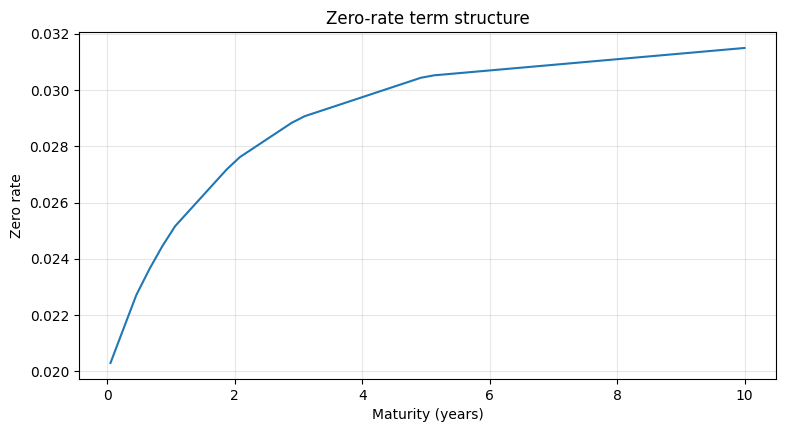

In [3]:
zero_dates = [
    eval_date,
    eval_date + ql.Period(1, ql.Months),
    eval_date + ql.Period(3, ql.Months),
    eval_date + ql.Period(6, ql.Months),
    eval_date + ql.Period(1, ql.Years),
    eval_date + ql.Period(2, ql.Years),
    eval_date + ql.Period(3, ql.Years),
    eval_date + ql.Period(5, ql.Years),
    eval_date + ql.Period(10, ql.Years),
]
zero_rates = [0.0200, 0.0205, 0.0215, 0.0230, 0.0250, 0.0275, 0.0290, 0.0305, 0.0315]

zero_curve = ql.ZeroCurve(zero_dates, zero_rates, day_counter, calendar)
zero_curve.enableExtrapolation()
discount_handle = ql.YieldTermStructureHandle(zero_curve)

# Quick look at the curve
ts = np.linspace(0.05, 10.0, 50)
zs = [zero_curve.zeroRate(t, ql.Continuous).rate() for t in ts]
plt.plot(ts, zs)
plt.title("Zero-rate term structure")
plt.xlabel("Maturity (years)"); plt.ylabel("Zero rate")
plt.grid(alpha=0.3); plt.show()

### 2.2 Per-asset dividend yield curves

Each underlying carries its own dividend stream. We model it as a smoothly
varying continuous yield (forward dividend yield). Realistic levels: a tech
index ~1%, a broad index ~2%, a value-heavy index ~3.5%.

In [4]:
asset_names = ["IDX_A", "IDX_B", "IDX_C"]
spots_initial = [5_500.0, 4_800.0, 38_000.0]   # realistic index levels

div_term_pillars = [
    eval_date,
    eval_date + ql.Period(1, ql.Years),
    eval_date + ql.Period(3, ql.Years),
    eval_date + ql.Period(5, ql.Years),
]
div_yield_by_asset = {
    "IDX_A": [0.0090, 0.0105, 0.0115, 0.0120],
    "IDX_B": [0.0190, 0.0205, 0.0215, 0.0220],
    "IDX_C": [0.0330, 0.0345, 0.0355, 0.0360],
}
dividend_handles = []
for name in asset_names:
    curve = ql.ZeroCurve(div_term_pillars, div_yield_by_asset[name], day_counter, calendar)
    curve.enableExtrapolation()
    dividend_handles.append(ql.YieldTermStructureHandle(curve))

for name, h in zip(asset_names, dividend_handles):
    qs = [h.zeroRate(t, ql.Continuous).rate() for t in (0.5, 1.0, 2.0, 3.0, 5.0)]
    print(f"{name:>6s} fwd div yield @ 0.5/1/2/3/5y: {np.round(qs, 4)}")

 IDX_A fwd div yield @ 0.5/1/2/3/5y: [0.0097 0.0105 0.011  0.0115 0.012 ]
 IDX_B fwd div yield @ 0.5/1/2/3/5y: [0.0197 0.0205 0.021  0.0215 0.022 ]
 IDX_C fwd div yield @ 0.5/1/2/3/5y: [0.0338 0.0345 0.035  0.0355 0.036 ]


### 2.3 Correlation matrix

Realistic equity-index pair correlations sit in **0.5–0.8** over multi-year
horizons. We use:

* `IDX_A` vs `IDX_B` = 0.75
* `IDX_A` vs `IDX_C` = 0.55
* `IDX_B` vs `IDX_C` = 0.60

`MarketData` validates symmetry, unit diagonal and positive-semi-definite-ness
on construction.

In [5]:
correlation = np.array([
    [1.00, 0.75, 0.55],
    [0.75, 1.00, 0.60],
    [0.55, 0.60, 1.00],
])
# Verify PSD ourselves to be sure.
print("eigenvalues:", np.linalg.eigvalsh(correlation))

eigenvalues: [0.246  0.4833 2.2707]


### 2.4 Assemble `MarketData`

`MarketData` is the single container that ties everything together. Spots are
stored as `ql.SimpleQuote` (mutable), so the same object can be bumped in
place for finite-difference Greeks later.

In [6]:
spot_quotes = [ql.SimpleQuote(s) for s in spots_initial]

market = MarketData(
    eval_date=eval_date,
    spots=spot_quotes,
    discount_curve=discount_handle,
    dividend_curves=dividend_handles,
    correlation=correlation,
    calendar=calendar,
    day_counter=day_counter,
)
print(f"N_assets = {market.n_assets}")
print(f"spots   = {[q.value() for q in market.spots]}")

N_assets = 3
spots   = [5500.0, 4800.0, 38000.0]


## 3. Approach A — direct implied vol matrix per asset

Equity index smiles are strongly **down-skewed** (puts more expensive than
calls). We mimic this with a simple parametric form:

$$
\sigma(K, T) = \sigma_{\text{ATM}}(T)\,\bigl(1 - \beta(T)\,m\bigr) + \kappa(T)\,m^{2},
\quad m = \log(K / F(T))
$$

where the **ATM term structure** is upward-sloping (typical for indices
during low realised-vol regimes) and the skew $\beta$ flattens with maturity.
This is a synthetic stand-in for a real market data fetch.

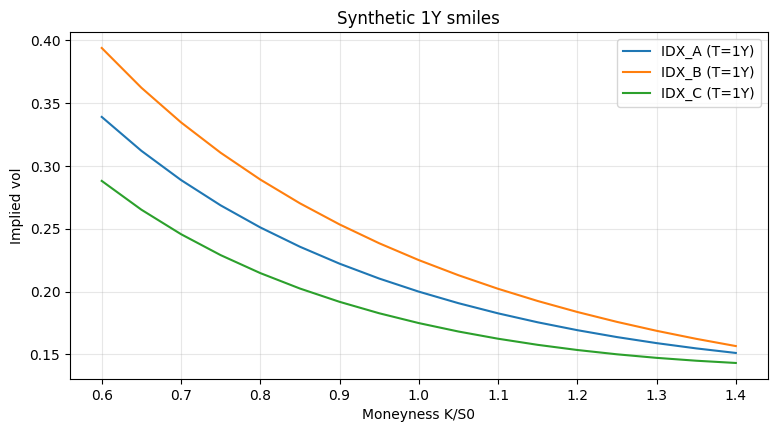

In [7]:
expiries = [eval_date + ql.Period(i, ql.Months) for i in (3, 6, 12, 18, 24, 30, 36)]
times = np.array([day_counter.yearFraction(eval_date, d) for d in expiries])

def synthetic_vol_matrix(spot: float, atm_short: float, atm_long: float,
                         skew_short: float, skew_long: float,
                         strikes: np.ndarray, expiries: list[ql.Date]) -> pd.DataFrame:
    times = np.array([day_counter.yearFraction(eval_date, d) for d in expiries])
    # ATM linearly grows from short to long maturity (typical contango)
    atm = atm_short + (atm_long - atm_short) * (times - times[0]) / (times[-1] - times[0])
    skew = skew_short + (skew_long - skew_short) * (times - times[0]) / (times[-1] - times[0])
    convexity = 0.12 + 0.02 * times          # convexity ~ 0.12-0.20
    vol = np.zeros((len(strikes), len(expiries)))
    for j, T in enumerate(times):
        # forward including the per-asset div yield
        # (we use spot * exp((r - q) * T); but for shape we just need a sensible forward)
        r_T = zero_curve.zeroRate(T, ql.Continuous).rate()
        q_T = 0.02  # average div used only to centre log-moneyness
        F = spot * math.exp((r_T - q_T) * T)
        m = np.log(strikes / F)
        vol[:, j] = atm[j] * (1.0 - skew[j] * m) + convexity[j] * m**2
        vol[:, j] = np.clip(vol[:, j], 0.05, 1.5)
    return pd.DataFrame(vol, index=strikes, columns=expiries)

# Per-asset strike grids around respective spots
strike_grids = {
    "IDX_A": np.linspace(0.60, 1.40, 17) * spots_initial[0],
    "IDX_B": np.linspace(0.60, 1.40, 17) * spots_initial[1],
    "IDX_C": np.linspace(0.60, 1.40, 17) * spots_initial[2],
}

vol_matrices = {
    "IDX_A": synthetic_vol_matrix(spots_initial[0], 0.18, 0.22, 1.2, 0.7,
                                   strike_grids["IDX_A"], expiries),
    "IDX_B": synthetic_vol_matrix(spots_initial[1], 0.20, 0.25, 1.4, 0.8,
                                   strike_grids["IDX_B"], expiries),
    "IDX_C": synthetic_vol_matrix(spots_initial[2], 0.16, 0.19, 1.0, 0.6,
                                   strike_grids["IDX_C"], expiries),
}

# Visual check: smile slices at 1Y per asset
fig, ax = plt.subplots(figsize=(9, 4.5))
for name in asset_names:
    grid = strike_grids[name]
    mness = grid / spots_initial[asset_names.index(name)]
    ax.plot(mness, vol_matrices[name].iloc[:, 3], label=f"{name} (T=1Y)")
ax.set_xlabel("Moneyness K/S0"); ax.set_ylabel("Implied vol")
ax.set_title("Synthetic 1Y smiles"); ax.grid(alpha=0.3); ax.legend()
plt.show()

In [10]:
vol_matrices['IDX_C']

,"August 15th, 2026","November 15th, 2026","May 15th, 2027","November 15th, 2027","May 15th, 2028","November 15th, 2028","May 15th, 2029"
22800.0,0.274469,0.277221,0.282714,0.288168,0.293551,0.298602,0.303402
24700.0,0.252231,0.254836,0.260054,0.265261,0.270418,0.275285,0.279927
26600.0,0.233070,0.235596,0.240674,0.245767,0.250828,0.255640,0.260250
28500.0,0.216465,0.218969,0.224014,0.229101,0.234170,0.239031,0.243709
30400.0,0.202011,0.204537,0.209636,0.214804,0.219967,0.224960,0.229788
32300.0,0.189382,0.191966,0.197192,0.202512,0.207840,0.213034,0.218077
34200.0,0.178316,0.180991,0.186402,0.191934,0.197484,0.202935,0.208248
36100.0,0.168601,0.171391,0.177038,0.182831,0.188650,0.194405,0.200033
38000.0,0.160061,0.162986,0.168910,0.175005,0.181135,0.187232,0.193212
39900.0,0.152547,0.155627,0.161863,0.168295,0.174768,0.181240,0.187604


### 3.1 Build the Black variance surface per asset

`build_black_variance_surface` wraps `ql.BlackVarianceSurface` (bilinear
interpolation, extrapolation on). The Dupire local-vol is derived
automatically by the process builder, so we just need the BVS per asset.

In [11]:
bvs_list = [
    build_black_variance_surface(eval_date, vol_matrices[name], calendar, day_counter)
    for name in asset_names
]
print("Black variance surfaces built:", [type(b).__name__ for b in bvs_list])

Black variance surfaces built: ['BlackVarianceSurface', 'BlackVarianceSurface', 'BlackVarianceSurface']


### 3.2 Assemble the correlated process array

`build_process_array` returns a `ql.StochasticProcessArray` whose components
are `GeneralizedBlackScholesProcess` instances with **Dupire local vol** on
top of the BVS. The asset correlation is applied internally on every step.

In [12]:
process_array = build_process_array(market, bvs_list)
print("size (n_assets):", process_array.size())
print("factors:        ", process_array.factors())
print("initial values: ", list(process_array.initialValues()))

size (n_assets): 3
factors:         3
initial values:  [5500.0, 4800.0, 38000.0]


### 3.3 Build the time grid

Autocall products check the basket on **predefined observation dates** —
typically every 3 or 6 months. The time grid must contain every obs date as
a *mandatory* node. Between obs dates we add **sub-steps** so the local-vol
Euler discretisation is accurate (and so American KI logic, when it's added
in the next PR, can be checked on a fine grid).

In [15]:
obs_dates = [eval_date + ql.Period(m, ql.Months) for m in (6, 12, 18, 24, 30, 36)]
steps_per_year = 24                                   # ~bi-weekly sub-steps
time_grid = build_time_grid(eval_date, obs_dates, steps_per_year, day_counter)
obs_idx = grid_indices_of_obs_dates(time_grid, eval_date, obs_dates, day_counter)

print(f"n_steps           = {len(time_grid) - 1}")
print(f"obs dates → indices: {obs_idx}")
print(f"obs times          : {[round(time_grid[i], 4) for i in obs_idx]}")

n_steps           = 72
obs dates → indices: [12, 24, 36, 48, 60, 72]
obs times          : [0.5041, 1.0, 1.5041, 2.0027, 2.5068, 3.0027]


### 3.4 Generate paths

`PathGenerator` exposes the diffusion engine. Important arguments:

| arg | meaning |
|-----|---------|
| `process_array`        | the correlated multi-asset process from §3.2 |
| `time_grid`            | from §3.3 |
| `n_paths`              | **power-of-two values** (e.g. `2**14`) maximise Sobol equidistribution |
| `seed`                 | deterministic — same seed always produces same paths |
| `bridge`               | `True` enables Brownian bridge across time (variance reduction) |
| `direction_integers`   | `"JoeKuoD7"` (default) is recommended for high dimensions |
| `antithetic`           | rarely useful with Sobol; default `False` |

Output is a contiguous `np.ndarray` of shape `(n_paths, n_assets, n_steps + 1)`.

In [16]:
n_paths = 2**14
t0 = time.time()
pg = PathGenerator(
    process_array=process_array,
    time_grid=time_grid,
    n_paths=n_paths,
    seed=20260515,
    bridge=True,
)
paths = pg.generate()
elapsed = time.time() - t0
print(f"generated paths shape = {paths.shape} in {elapsed:.2f}s")

generated paths shape = (16384, 3, 73) in 26.70s


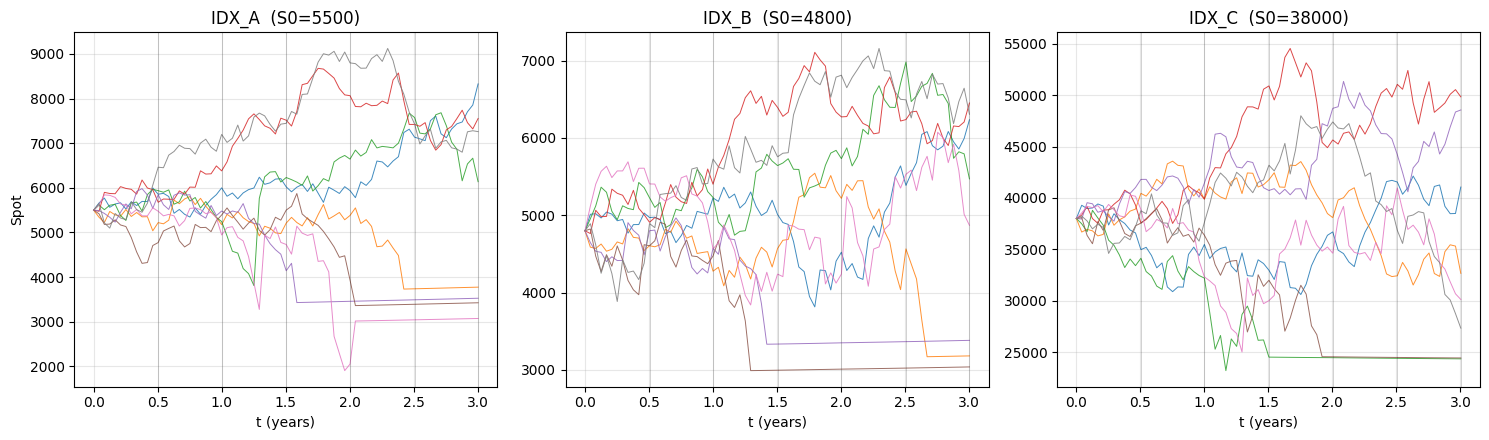

In [19]:
# Plot 8 sample paths per asset
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
grid_times = np.array([time_grid[i] for i in range(len(time_grid))])
for a, (ax, name) in enumerate(zip(axes, asset_names)):
    for p in range(8):
        ax.plot(grid_times, paths[p, a, :], lw=0.7, alpha=0.85)
    # Mark observation dates
    for idx in obs_idx:
        ax.axvline(grid_times[idx], color="k", lw=0.4, alpha=0.3)
    ax.set_title(f"{name}  (S0={spots_initial[a]:.0f})")
    ax.set_xlabel("t (years)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Spot")
plt.tight_layout(); plt.show()

## 4. Approach B — calibrate SVI to noisy market quotes

In production, market vol quotes come with **bid-ask noise** and from a
**sparse** strike grid. Fitting a parametric model (raw SVI here) gives a
smooth, arbitrage-aware surface that you can resample on any (K, T) pair.

We synthesise noisy quotes from Approach A's surface, then fit and resample.

In [20]:
# Take Approach A's vol matrix for IDX_A, add 1% noise on a coarser strike grid,
# then fit SVI per slice.
np.random.seed(42)
coarse_strikes = np.linspace(0.75, 1.25, 9) * spots_initial[0]

# Forwards per expiry (consistent with rate / div curves of asset 0)
forwards = []
for T, d in zip(times, expiries):
    rT = zero_curve.zeroRate(T, ql.Continuous).rate()
    qT = dividend_handles[0].zeroRate(T, ql.Continuous).rate()
    forwards.append(spots_initial[0] * math.exp((rT - qT) * T))

# Resample the smooth A-surface onto coarse strikes, then add noise.
clean = synthetic_vol_matrix(spots_initial[0], 0.18, 0.22, 1.2, 0.7,
                              coarse_strikes, expiries)
noise = np.random.normal(scale=0.003, size=clean.shape)   # ~30 bp Black-vol noise
noisy_quotes = clean + noise
print("Noisy quote sample (1Y slice):")
print(noisy_quotes.iloc[:, 3].round(4))

Noisy quote sample (1Y slice):
4125.00    0.2733
4468.75    0.2457
4812.50    0.2298
5156.25    0.2116
5500.00    0.2056
5843.75    0.1847
6187.50    0.1769
6531.25    0.1688
6875.00    0.1668
Name: November 15th, 2027, dtype: float64


In [21]:
svi_surface = fit_svi_surface(eval_date, noisy_quotes, forwards, day_counter)

# Check calendar arbitrage on the fitted surface
ok = svi_surface.check_calendar_arbitrage()
print(f"Calendar arb-free? {ok}")

Calendar arb-free? False


c:\OneDrive\Pulpit\autocall\src\autocall\vol\svi.py:151: UserWarning: Calendar arbitrage between expiry 3 (November 15th, 2027) and 4 (May 15th, 2028).
  warnings.warn(


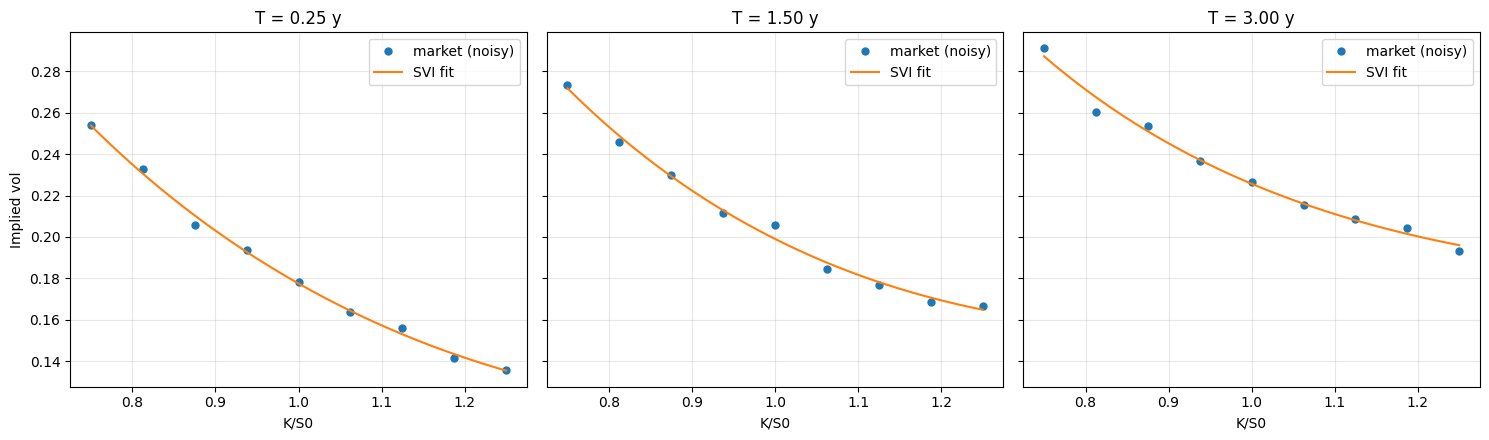

In [22]:
# Compare market vs SVI fit at three maturities
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, j in zip(axes, (0, 3, 6)):
    K = np.linspace(coarse_strikes.min(), coarse_strikes.max(), 80)
    iv_fit = np.array([svi_surface.implied_vol(float(k), j) for k in K])
    ax.plot(coarse_strikes / spots_initial[0], noisy_quotes.iloc[:, j], "o",
            label="market (noisy)", ms=5)
    ax.plot(K / spots_initial[0], iv_fit, "-", label="SVI fit")
    ax.set_title(f"T = {times[j]:.2f} y"); ax.set_xlabel("K/S0"); ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Implied vol")
plt.tight_layout(); plt.show()

### 4.1 Resample to a Black variance surface

Once the SVI surface is calibrated, resample it on a **dense** strike grid
and wrap it back into `BlackVarianceSurface`. The rest of the pipeline
(local vol, process, path generator) is identical.

In [23]:
dense_strikes = np.linspace(0.55, 1.45, 25) * spots_initial[0]
bvs_svi_a = svi_to_black_variance_surface(
    eval_date, svi_surface, strike_grid=list(dense_strikes),
    calendar=calendar, day_counter=day_counter,
)

# Drop in to replace Approach A's surface for IDX_A; keep IDX_B and IDX_C as before.
bvs_list_svi = [bvs_svi_a, bvs_list[1], bvs_list[2]]
process_array_svi = build_process_array(market, bvs_list_svi)

pg_svi = PathGenerator(process_array_svi, time_grid, n_paths=2**13,
                       seed=20260515, bridge=True)
paths_svi = pg_svi.generate()
print("SVI-calibrated paths shape:", paths_svi.shape)

SVI-calibrated paths shape: (8192, 3, 73)


## 5. Diagnostics and sanity checks

### 5.1 Terminal marginal distributions

Histograms of the 3-year terminal spot, per asset. The right-skew is the
classic lognormal-like footprint amplified by the negative skew of the
implied vol surface.

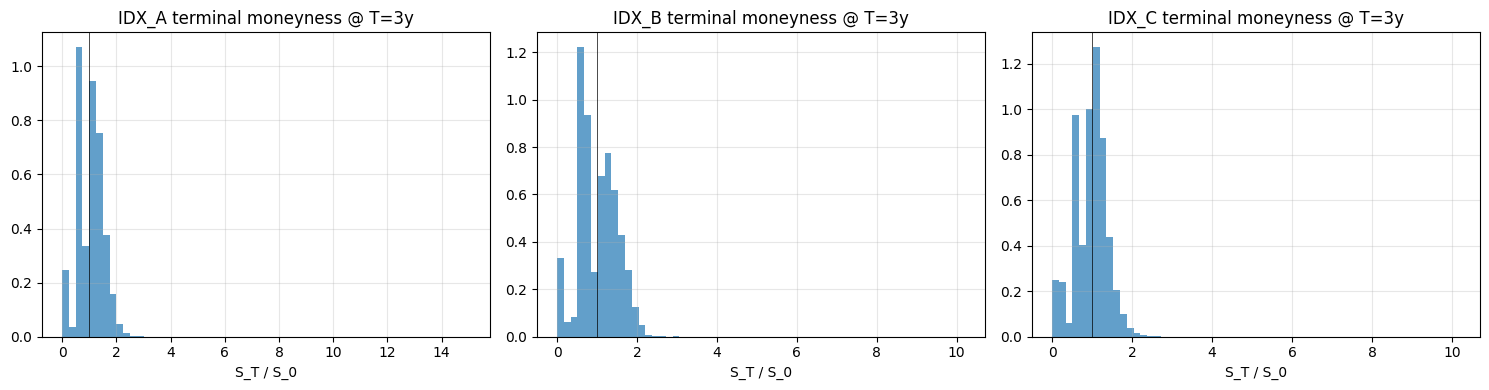

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
T_idx = obs_idx[-1]
for a, (ax, name) in enumerate(zip(axes, asset_names)):
    terminal = paths[:, a, T_idx]
    ax.hist(terminal / spots_initial[a], bins=60, alpha=0.7, density=True)
    ax.axvline(1.0, color="k", lw=0.5)
    ax.set_title(f"{name} terminal moneyness @ T=3y")
    ax.set_xlabel("S_T / S_0"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.2 Empirical correlation of log-returns

The Monte-Carlo correlation should match the input matrix to within sampling
error.

In [25]:
log_ret = np.diff(np.log(paths), axis=2)
flat = log_ret.transpose(1, 0, 2).reshape(market.n_assets, -1)
empirical_corr = np.corrcoef(flat)
print("Input correlation:")
print(correlation)
print("\nEmpirical correlation (Sobol+BB, n=2**14):")
print(empirical_corr.round(3))
print("\nMax abs error:", np.max(np.abs(empirical_corr - correlation)).round(4))

Input correlation:
[[1.   0.75 0.55]
 [0.75 1.   0.6 ]
 [0.55 0.6  1.  ]]

Empirical correlation (Sobol+BB, n=2**14):
[[1.    0.142 0.189]
 [0.142 1.    0.113]
 [0.189 0.113 1.   ]]

Max abs error: 0.6081


### 5.3 Variance reduction from the Brownian bridge

We price a 3-year European call on `IDX_A` two ways:

* `bridge=False`: Sobol normals fed step-by-step (Euler).
* `bridge=True` : same Sobol normals reshuffled through the bridge.

Both converge to the same value (the SDE is identical); the bridge variant
typically reaches it with a **smaller standard error per path** for any
payoff that depends on the *terminal* slice — because Sobol's first
coordinates govern the longest-time-scale Brownian motions, capturing the
most variance early.

In [26]:
strike = spots_initial[0]
T = day_counter.yearFraction(eval_date, obs_dates[-1])
disc = math.exp(-zero_curve.zeroRate(T, ql.Continuous).rate() * T)

def euro_call_mc(bridge: bool, n_paths: int, seed: int = 1234) -> tuple[float, float]:
    pg_local = PathGenerator(process_array, time_grid, n_paths=n_paths,
                             seed=seed, bridge=bridge)
    P = pg_local.generate()
    payoff = np.maximum(P[:, 0, obs_idx[-1]] - strike, 0.0) * disc
    return float(payoff.mean()), float(payoff.std(ddof=1) / math.sqrt(n_paths))

rows = []
for n in (2**10, 2**12, 2**14):
    pm, sm = euro_call_mc(bridge=False, n_paths=n)
    pb, sb = euro_call_mc(bridge=True,  n_paths=n)
    rows.append((n, pm, sm, pb, sb, sm / sb if sb > 0 else float("nan")))

df = pd.DataFrame(rows, columns=["n_paths", "price (Euler)", "SE (Euler)",
                                  "price (Bridge)", "SE (Bridge)",
                                  "SE ratio (Euler/Bridge)"])
df

,n_paths,price (Euler),SE (Euler),price (Bridge),SE (Bridge),SE ratio (Euler/Bridge)
0,1024,912.074167,40.247964,1074.176200,51.320983,0.784240
1,4096,1028.732154,23.439469,1088.337056,27.221065,0.861078
2,16384,1073.699359,16.410209,1082.755978,12.991660,1.263134


The SE ratio > 1 means the bridge variant achieves the same precision with
fewer paths. The effect grows for **path-dependent** payoffs (autocalls,
Asian options, barrier options) and for higher dimension.

### 5.4 Sobol determinism

Same seed ⇒ bitwise-identical paths. Critical for bump-and-revalue Greeks.

In [27]:
a = PathGenerator(process_array, time_grid, n_paths=256, seed=99, bridge=True).generate()
b = PathGenerator(process_array, time_grid, n_paths=256, seed=99, bridge=True).generate()
print("identical:", np.array_equal(a, b))

identical: True


## 6. Usage tips and gotchas

* **Power-of-two `n_paths`.** Sobol is balanced at $2^k$ samples; using a
  non-power-of-two count works but degrades the equidistribution slightly.

* **Mandatory observation dates.** `build_time_grid(eval_date, obs_dates,
  steps_per_year)` guarantees every observation date is a grid node. If you
  later add a payoff, index into the path with
  `grid_indices_of_obs_dates(time_grid, eval_date, obs_dates)`.

* **Spot bumps for Greeks.** `MarketData.spots` are `ql.SimpleQuote`; call
  `q.setValue(new_spot)` and re-generate. The vol surface holds a
  `QuoteHandle` so it observes the bump automatically. *Reuse the same
  seed across +ε and -ε runs* — Sobol determinism is what makes pathwise
  finite-difference Greeks well-behaved.

* **Dividend-spot consistency.** `MarketData.flat(...)` builds flat curves
  for quick tests; use the explicit constructor with handcrafted
  `YieldTermStructureHandle` objects (as in §2.1–2.4) for production.

* **Correlation matrix must be PSD.** `MarketData` checks symmetry, unit
  diagonal and PSD; if your matrix fails, either fix the source or apply a
  nearest-PSD projection (eigenvalue clipping). The library marks this as
  a TODO.

* **Local-vol holes.** Beyond the calibration grid Dupire can produce
  arbitrage holes. `NoExceptLocalVolSurface` is used internally with a
  vol floor of 1e-4 so path generation never crashes — but pricing too
  far outside the calibration grid is still **extrapolation** and should
  be flagged.

* **What the Brownian bridge does, in one line.** It permutes the
  $n_{\text{steps}}$ standard normals along the time axis so that the
  *first* Sobol coordinates control the *longest* time-scale Brownian
  motions. Sobol balances its first coordinates best — so concentrating
  variance there reduces MC error.

* **`GaussianSobolMultiPathGenerator(... brownianBridge=True)` is broken
  in QuantLib for generic SDEs.** It throws *"Brownian bridge not
  supported"*. This library steps the process manually with
  `ql.BrownianBridge.transform` for that reason. The construction is
  exact — the bridge transform produces $\mathcal{N}(0,1)$ variates per
  step that the process scales by $\sigma\sqrt{\Delta t}$ internally.

* **What is *not* in this PR.** Payoffs (Phoenix, Athena, Snowball with
  European / American KI), discounting + PV aggregation, Greeks, and
  correlation calibration to multi-asset quotes. See
  `src/autocall/payoff/NOTES.md` for the planned scope.